# 15 · K-Means Clustering — Batch Reactor Operating Mode Detection

> *"Unsupervised learning doesn't find what you're looking for.  
> It finds what's actually there."*

---

## 🏭 Business Context

A **batch reactor** in a chemical plant doesn't fail the same way twice.  
Sometimes it runs too cold and the reaction drags on, wasting time and energy.  
Sometimes it runs too hot and the exothermic reaction accelerates beyond control — a **runaway** scenario.  
Sometimes the cooling system is silently degraded: temperature climbs, pressure rises, and no alarm fires because no individual sensor crosses a hard threshold.  

Traditional process control addresses each of these as separate problems with separate rules.  
**K-Means clustering takes a different approach**: instead of defining the modes manually, we let the data reveal them.

This notebook applies K-Means to **1,500 batch production records** collected from process historians, covering:
- Peak temperature and pressure per batch
- Agitation speed (rpm)
- Reactant concentrations (A and B)
- Cooling flow rate
- Reaction duration
- Final conversion yield (%)

The algorithm discovers **4 distinct operating modes** — purely from the multivariate signal pattern.  
No labels. No prior knowledge. No assumptions about which batch was 'good' or 'bad'.

The output: a **batch classifier** that assigns any new production run to one of the four operational regimes, enabling targeted corrective action before risk escalates.

---

**Project:** 15 | **Algorithm:** K-Means Clustering | **Domain:** Chemical Process Engineering  
**Family:** Unsupervised Learning · Partitional Clustering  
**Status:** ✅ Free Project — Full Dataset + App Included

---

## ⚙️ Section 2 — Setup

In [1]:
# ── Core libraries ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.patches import FancyBboxPatch

# ── Machine Learning ─────────────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    adjusted_rand_score,
    normalized_mutual_info_score
)
from sklearn.neighbors import NearestNeighbors

# ── Display ──────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

# ── LozanoLsa palette ────────────────────────────────────────────────────────
C_BLUE   = "#4C9BE8"   # primary brand
C_RED    = "#E8574C"   # alert / warning
C_GREEN  = "#3FB950"   # normal / safe
C_AMBER  = "#F0A84D"   # caution
C_PURPLE = "#A371F7"   # cluster accent 4

# Cluster color map (Cluster 0 → 3)
CLUSTER_COLORS = {
    0: C_AMBER,    # Slow Reaction / Low Yield
    1: C_PURPLE,   # Poor Heat Transfer
    2: C_GREEN,    # Normal Operation
    3: C_RED,      # Aggressive / Runaway Risk
}
CLUSTER_NAMES = {
    0: "Slow Reaction / Low Yield",
    1: "Poor Heat Transfer",
    2: "Normal Operation",
    3: "Aggressive / Runaway Risk",
}

# Aesthetic defaults
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.05)
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (10, 5)})

print("✅ Environment ready — Project 15 · K-Means Clustering")

✅ Environment ready — Project 15 · K-Means Clustering


## 📂 Section 3 — Load Data

**Dataset:** `reactor_batch.csv` — 1,500 batch production records from a chemical plant reactor historian.

| Column | Type | Unit | Description |
|---|---|---|---|
| `temp_max_c` | float | °C | Peak temperature reached during the batch |
| `pressure_max_bar` | float | bar | Maximum pressure recorded |
| `agitation_rpm` | float | rpm | Stirrer/agitator speed |
| `conc_a_initial_pct` | float | % | Initial concentration of reactant A |
| `conc_b_initial_pct` | float | % | Initial concentration of reactant B |
| `cooling_flow_l_min` | float | L/min | Cooling jacket flow rate |
| `reaction_time_min` | float | min | Total batch duration |
| `final_conversion_pct` | float | % | Reactant conversion at end of batch |
| `cluster_true` | int | — | Ground-truth operating mode (held out — used only for external validation) |

> ⚠️ **Note:** `cluster_true` is available for external validation but is **not used during model training**.  
> K-Means operates in fully unsupervised mode — the algorithm sees only the 8 process variables.

In [2]:
# ── Portable loader ──────────────────────────────────────────────────────────
try:
    df = pd.read_csv("reactor_batch.csv")
except FileNotFoundError:
    df = pd.read_csv(
        "https://raw.githubusercontent.com/LozanoLsa/"
        "KMeans_Runaway_Risk/main/reactor_batch.csv"
    )

# Feature list (no target — unsupervised)
FEATURES = [
    "temp_max_c", "pressure_max_bar", "agitation_rpm",
    "conc_a_initial_pct", "conc_b_initial_pct",
    "cooling_flow_l_min", "reaction_time_min", "final_conversion_pct"
]

print(f"Dataset shape : {df.shape}")
print(f"Features      : {len(FEATURES)} process variables")
print(f"Records       : {len(df):,} batch production runs")
print(f"Missing values: {df.isnull().sum().sum()}")
df.head()

Dataset shape : (1500, 9)
Features      : 8 process variables
Records       : 1,500 batch production runs
Missing values: 0


,temp_max_c,pressure_max_bar,agitation_rpm,conc_a_initial_pct,conc_b_initial_pct,cooling_flow_l_min,reaction_time_min,final_conversion_pct,cluster_true
0,80.91,2.37,262.75,31.21,35.77,88.76,82.16,98.95,0
1,76.88,2.94,293.88,35.09,29.86,100.82,72.73,92.91,0
2,82.25,2.54,303.29,38.09,32.86,101.73,83.35,96.22,0
3,82.82,2.58,373.35,28.36,37.32,83.47,78.93,93.63,0
4,74.15,2.97,258.68,36.04,34.16,89.66,75.13,95.16,0


## 🔍 Section 4 — Sanity Checks

Before clustering, we verify data completeness, numeric ranges, and physical plausibility.  
In an unsupervised pipeline there is no target to check for imbalance —  
instead, we confirm that each variable spans a physically meaningful range and that no column is trivially constant.

In [3]:
# ── Descriptive statistics ───────────────────────────────────────────────────
print("=" * 60)
print("  Descriptive Statistics — Feature Space")
print("=" * 60)
desc = df[FEATURES].describe().T
desc["cv_%"] = (desc["std"] / desc["mean"] * 100).round(1)  # coefficient of variation
display(desc.round(2))

# ── Physical range check ─────────────────────────────────────────────────────
bounds = {
    "temp_max_c":           (55, 120),
    "pressure_max_bar":     (1.0, 8.0),
    "agitation_rpm":        (100, 500),
    "conc_a_initial_pct":   (20, 60),
    "conc_b_initial_pct":   (20, 60),
    "cooling_flow_l_min":   (20, 130),
    "reaction_time_min":    (40, 150),
    "final_conversion_pct": (70, 100),
}
print("\n── Physical range violations ───────────────────────────")
violations = 0
for col, (lo, hi) in bounds.items():
    out = df[(df[col] < lo) | (df[col] > hi)].shape[0]
    if out > 0:
        print(f"  ⚠️  {col}: {out} values outside [{lo}, {hi}]")
        violations += 1
if violations == 0:
    print("  ✅ All variables within physical operating bounds.")

# ── Variance check (constant columns fail clustering) ────────────────────────
print("\n── Zero-variance columns ───────────────────────────────")
zero_var = [c for c in FEATURES if df[c].std() < 1e-6]
if zero_var:
    print(f"  ⚠️  Constant columns detected: {zero_var}")
else:
    print("  ✅ All features have non-zero variance — safe to cluster.")

  Descriptive Statistics — Feature Space


,count,mean,std,min,25%,50%,75%,max,cv_%
temp_max_c,1500.00,83.32,11.99,58.78,73.82,81.39,93.77,114.02,14.40
pressure_max_bar,1500.00,2.95,1.00,1.06,2.19,2.63,3.65,6.68,34.00
agitation_rpm,1500.00,291.70,62.26,148.26,245.28,288.79,329.89,500.00,21.30
conc_a_initial_pct,1500.00,34.43,4.55,20.00,31.21,34.32,37.10,51.01,13.20
conc_b_initial_pct,1500.00,34.76,4.67,20.00,31.70,34.60,37.82,49.90,13.40
cooling_flow_l_min,1500.00,77.57,23.61,23.82,55.53,84.73,96.20,130.00,30.40
reaction_time_min,1500.00,83.26,17.40,40.42,71.13,82.84,94.85,133.00,20.90
final_conversion_pct,1500.00,92.03,5.29,75.81,87.87,93.37,96.37,100.00,5.70



── Physical range violations ───────────────────────────
  ✅ All variables within physical operating bounds.

── Zero-variance columns ───────────────────────────────
  ✅ All features have non-zero variance — safe to cluster.


## 📊 Section 5 — Exploratory Data Analysis

Three visualizations orient us before clustering:

1. **Correlation heatmap** — which variables move together?  
   High correlations hint at latent structure (and inform PCA later).
2. **PCA 2D projection** — a low-dimensional view of the 8D feature space,  
   colored by the held-out ground truth to see if natural groups exist.
3. **Feature boxplots by operating mode** — using `cluster_true` to inspect  
   the characteristic signature of each mode (purely exploratory, not used for training).

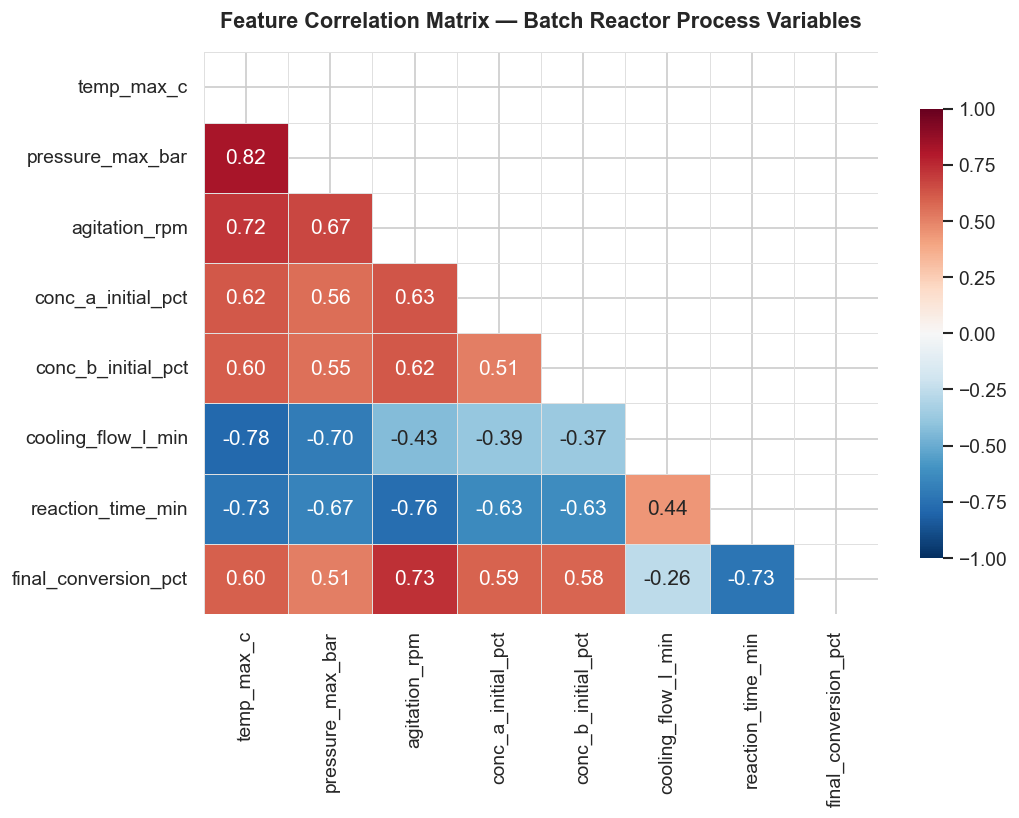


── Key correlation insights ────────────────────────────
  • temp_max_c ↔ pressure_max_bar  : 0.82
  • temp_max_c ↔ cooling_flow_l_min: -0.78
  • temp_max_c ↔ reaction_time_min : -0.73
  • cooling_flow ↔ reaction_time    : 0.44

  → Temp and pressure are strongly correlated: higher temperature
    drives pressure buildup — a classic exothermic signature.
  → Cooling flow correlates negatively with temperature:
    insufficient cooling allows heat to accumulate.
  → Reaction time is shorter when temperature is higher,
    consistent with Arrhenius kinetics.


In [4]:
# ── EDA 1 · Correlation heatmap ──────────────────────────────────────────────
corr = df[FEATURES].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))  # upper triangle only
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f",
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor="#e0e0e0",
    cbar_kws={"shrink": 0.8}, ax=ax
)
ax.set_title(
    "Feature Correlation Matrix — Batch Reactor Process Variables",
    fontsize=13, fontweight="bold", pad=15
)
plt.tight_layout()
plt.show()

# Key observations
print("\n── Key correlation insights ────────────────────────────")
print("  • temp_max_c ↔ pressure_max_bar  :", f"{corr.loc['temp_max_c','pressure_max_bar']:.2f}")
print("  • temp_max_c ↔ cooling_flow_l_min:", f"{corr.loc['temp_max_c','cooling_flow_l_min']:.2f}")
print("  • temp_max_c ↔ reaction_time_min :", f"{corr.loc['temp_max_c','reaction_time_min']:.2f}")
print("  • cooling_flow ↔ reaction_time    :", f"{corr.loc['cooling_flow_l_min','reaction_time_min']:.2f}")
print()
print("  → Temp and pressure are strongly correlated: higher temperature")
print("    drives pressure buildup — a classic exothermic signature.")
print("  → Cooling flow correlates negatively with temperature:")
print("    insufficient cooling allows heat to accumulate.")
print("  → Reaction time is shorter when temperature is higher,")
print("    consistent with Arrhenius kinetics.")

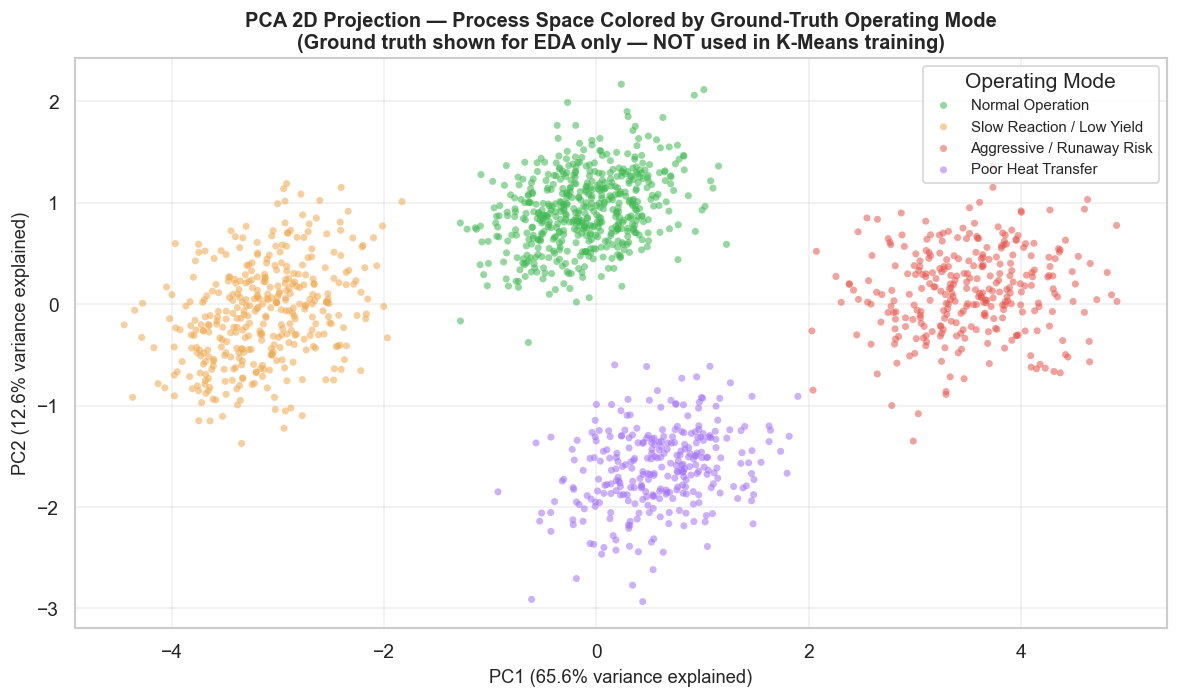

PCA cumulative variance explained (2 components): 78.3%
  → The four operating modes form clearly separated regions in PCA space.
    K-Means should be able to recover them from the raw process variables.


In [5]:
# ── EDA 2 · PCA 2D projection (colored by ground truth) ──────────────────────
# We use the held-out cluster_true ONLY for visualization here —
# the model will NOT see it during training.

scaler_eda = StandardScaler()
X_eda = scaler_eda.fit_transform(df[FEATURES])
pca_eda = PCA(n_components=2, random_state=42)
X_pca = pca_eda.fit_transform(X_eda)

true_names = {
    0: "Normal Operation",
    1: "Slow Reaction / Low Yield",
    2: "Aggressive / Runaway Risk",
    3: "Poor Heat Transfer",
}
true_colors = {
    0: C_GREEN, 1: C_AMBER, 2: C_RED, 3: C_PURPLE
}

fig, ax = plt.subplots(figsize=(10, 6))
for mode, name in true_names.items():
    mask = df["cluster_true"] == mode
    ax.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=true_colors[mode], label=name,
        alpha=0.55, s=18, edgecolors="none"
    )

var_exp = pca_eda.explained_variance_ratio_ * 100
ax.set_xlabel(f"PC1 ({var_exp[0]:.1f}% variance explained)", fontsize=11)
ax.set_ylabel(f"PC2 ({var_exp[1]:.1f}% variance explained)", fontsize=11)
ax.set_title(
    "PCA 2D Projection — Process Space Colored by Ground-Truth Operating Mode\n"
    "(Ground truth shown for EDA only — NOT used in K-Means training)",
    fontsize=12, fontweight="bold"
)
ax.legend(title="Operating Mode", loc="upper right", fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"PCA cumulative variance explained (2 components): {sum(var_exp):.1f}%")
print("  → The four operating modes form clearly separated regions in PCA space.")
print("    K-Means should be able to recover them from the raw process variables.")

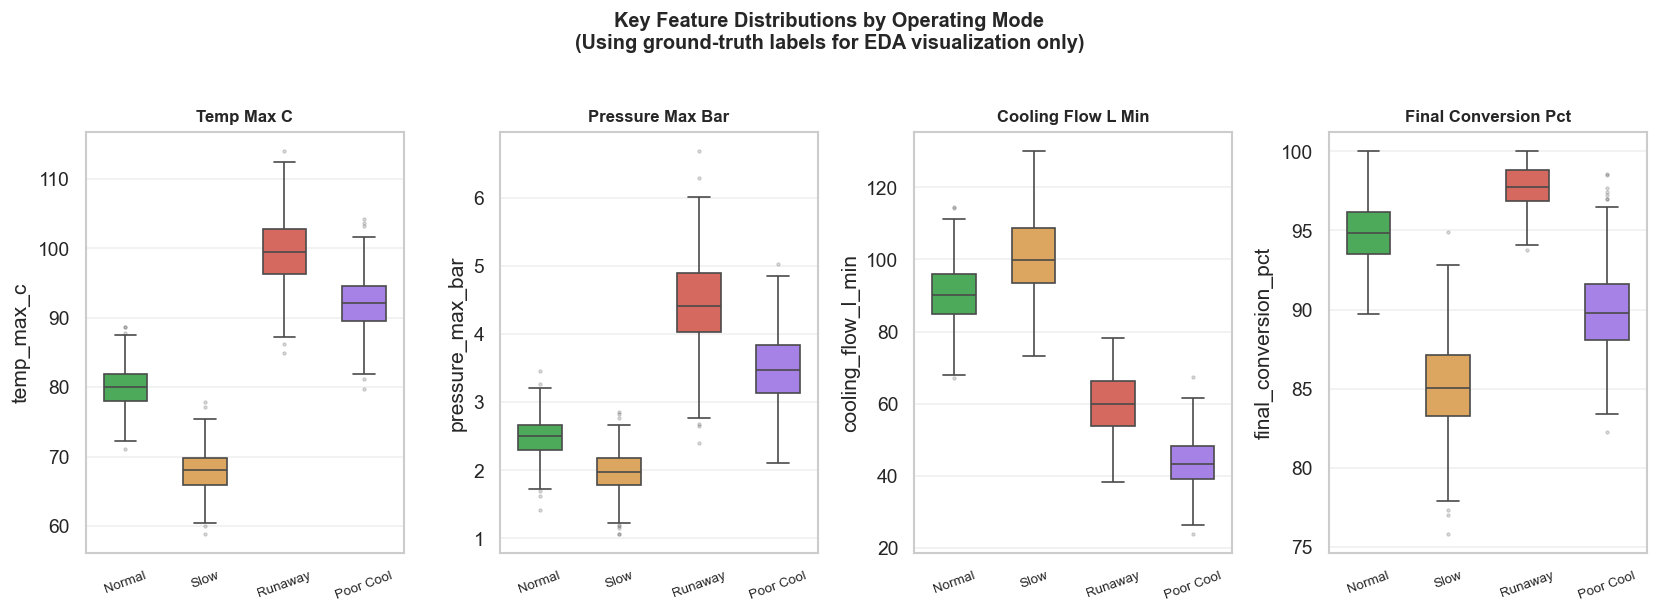

── Mode signatures ─────────────────────────────────────
  Normal      : moderate temp, good cooling, high conversion
  Slow        : low temp, excessive cooling, low conversion
  Runaway     : very high temp & pressure, low cooling, max conversion
  Poor Cool   : elevated temp, critically low cooling flow


In [6]:
# ── EDA 3 · Feature distributions by operating mode ──────────────────────────
key_vars = [
    "temp_max_c", "pressure_max_bar",
    "cooling_flow_l_min", "final_conversion_pct"
]
labels_map = {0: "Normal", 1: "Slow", 2: "Runaway", 3: "Poor Cool"}
palette_map = [C_GREEN, C_AMBER, C_RED, C_PURPLE]

df_plot = df.copy()
df_plot["mode"] = df_plot["cluster_true"].map(labels_map)
order = ["Normal", "Slow", "Runaway", "Poor Cool"]

fig, axes = plt.subplots(1, 4, figsize=(14, 5))
for ax, var in zip(axes, key_vars):
    sns.boxplot(
        data=df_plot, x="mode", y=var, order=order,
        palette=palette_map, width=0.55,
        flierprops={"marker": ".", "alpha": 0.3, "markersize": 3},
        ax=ax
    )
    ax.set_xlabel("")
    ax.set_title(var.replace("_", " ").title(), fontsize=10, fontweight="bold")
    ax.tick_params(axis="x", labelsize=8, rotation=20)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle(
    "Key Feature Distributions by Operating Mode\n"
    "(Using ground-truth labels for EDA visualization only)",
    fontsize=12, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.show()

print("── Mode signatures ─────────────────────────────────────")
print("  Normal      : moderate temp, good cooling, high conversion")
print("  Slow        : low temp, excessive cooling, low conversion")
print("  Runaway     : very high temp & pressure, low cooling, max conversion")
print("  Poor Cool   : elevated temp, critically low cooling flow")

## 🔧 Section 6 — Preprocessing

K-Means computes Euclidean distances in the feature space.  
If variables are on different scales (e.g., temperature in °C vs. flow in L/min),  
the algorithm would implicitly weight high-magnitude variables more heavily.

**`StandardScaler`** transforms each feature to zero mean and unit variance,  
placing all variables on equal footing before distance computation.

> There is **no train/test split** in this unsupervised pipeline.  
> The entire dataset is used to discover the cluster structure.  
> Model quality is assessed with **internal validation metrics** (Silhouette, Davies-Bouldin, Calinski-Harabasz)  
> and **external validation** against the held-out `cluster_true` column.

In [7]:
# ── Feature matrix ───────────────────────────────────────────────────────────
X = df[FEATURES].values

# ── StandardScaler ───────────────────────────────────────────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Feature matrix shape : {X.shape}")
print(f"Scaled matrix shape  : {X_scaled.shape}")
print(f"Post-scaling mean    : {X_scaled.mean(axis=0).round(6)}  (all ≈ 0)")
print(f"Post-scaling std     : {X_scaled.std(axis=0).round(6)}   (all ≈ 1)")

# ── PCA for downstream 2D visualization ──────────────────────────────────────
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f"\nPCA (2 components) variance explained: "
      f"{pca.explained_variance_ratio_.sum() * 100:.1f}%")

Feature matrix shape : (1500, 8)
Scaled matrix shape  : (1500, 8)
Post-scaling mean    : [-0.  0.  0. -0.  0. -0.  0. -0.]  (all ≈ 0)
Post-scaling std     : [1. 1. 1. 1. 1. 1. 1. 1.]   (all ≈ 1)

PCA (2 components) variance explained: 78.3%


## 🔢 Section 7 — Model Selection: Elbow + Silhouette Analysis

K-Means requires the number of clusters **k** as a hyperparameter.  
We choose k by running the algorithm for k = 2 to 9 and evaluating two complementary signals:

- **Elbow Curve** (Inertia) — total within-cluster sum of squared distances.  
  Decreases monotonically with k; the optimal k is at the "elbow" where the rate of decrease slows.

- **Silhouette Score** — measures cohesion vs. separation for each point.  
  Range: −1 to +1. Higher is better. Peaks at the most natural cluster count.

Both criteria should agree — or we choose the k that balances the two.

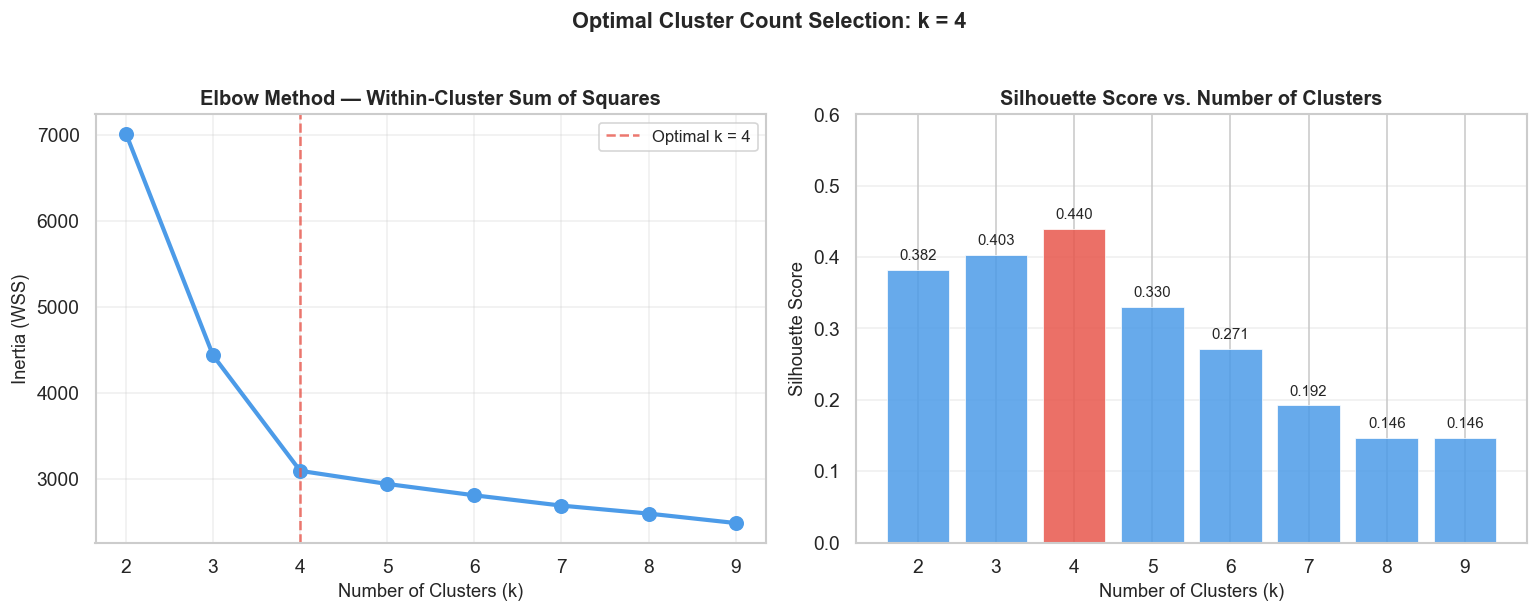


── K selection results ─────────────────────────────────
   k     Inertia    Silhouette
------------------------------
   2      7013.2        0.3822
   3      4435.2        0.4025
   4      3094.4        0.4396  ← optimal
   5      2942.0        0.3295
   6      2810.0        0.2714
   7      2690.4        0.1921
   8      2597.7        0.1460
   9      2487.8        0.1463

  → k=4 is the clear elbow point and achieves the highest silhouette.
    Both criteria converge on the same answer.


In [8]:
# ── Elbow + Silhouette sweep ─────────────────────────────────────────────────
K_RANGE = range(2, 10)
inertias, sil_scores = [], []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels_k = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels_k))

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Left: Elbow
ks = list(K_RANGE)
ax1.plot(ks, inertias, "o-", color=C_BLUE, linewidth=2.5, markersize=8)
ax1.axvline(x=4, color=C_RED, linestyle="--", linewidth=1.5, alpha=0.8, label="Optimal k = 4")
ax1.set_xlabel("Number of Clusters (k)", fontsize=11)
ax1.set_ylabel("Inertia (WSS)", fontsize=11)
ax1.set_title("Elbow Method — Within-Cluster Sum of Squares", fontsize=12, fontweight="bold")
ax1.set_xticks(ks)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Right: Silhouette
colors = [C_RED if k == 4 else C_BLUE for k in ks]
bars = ax2.bar(ks, sil_scores, color=colors, alpha=0.85, edgecolor="white", linewidth=0.5)
ax2.set_xlabel("Number of Clusters (k)", fontsize=11)
ax2.set_ylabel("Silhouette Score", fontsize=11)
ax2.set_title("Silhouette Score vs. Number of Clusters", fontsize=12, fontweight="bold")
ax2.set_xticks(ks)
ax2.set_ylim(0, 0.6)
ax2.grid(axis="y", alpha=0.3)
for bar, score in zip(bars, sil_scores):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
             f"{score:.3f}", ha="center", va="bottom", fontsize=9)

plt.suptitle("Optimal Cluster Count Selection: k = 4",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# Print results table
print("\n── K selection results ─────────────────────────────────")
print(f"{'k':>4}  {'Inertia':>10}  {'Silhouette':>12}")
print("-" * 30)
for k, ine, sil in zip(ks, inertias, sil_scores):
    marker = "  ← optimal" if k == 4 else ""
    print(f"{k:>4}  {ine:>10.1f}  {sil:>12.4f}{marker}")

print("\n  → k=4 is the clear elbow point and achieves the highest silhouette.")
print("    Both criteria converge on the same answer.")

## 🤖 Section 8 — Model Training

With **k = 4** confirmed, we train the final K-Means model using:
- `n_init=20`: run the algorithm 20 times with different centroid initializations  
  and keep the best result (lowest inertia).
- `random_state=42`: ensures reproducibility across runs.

After fitting, we map each cluster to its operational interpretation  
and cross-validate against the held-out ground truth.

In [9]:
# ── Final model ──────────────────────────────────────────────────────────────
K_OPT = 4
kmeans = KMeans(n_clusters=K_OPT, random_state=42, n_init=20)
cluster_labels = kmeans.fit_predict(X_scaled)
df["cluster_kmeans"] = cluster_labels

# ── Cluster distribution ─────────────────────────────────────────────────────
print("── Cluster Assignment Distribution ─────────────────────")
for c in range(K_OPT):
    n = (cluster_labels == c).sum()
    pct = n / len(cluster_labels) * 100
    print(f"  Cluster {c} — {CLUSTER_NAMES[c]:<35}: {n:>4} batches ({pct:.1f}%)")

# ── Cross-tab vs ground truth ─────────────────────────────────────────────────
print("\n── Cross-tabulation: Ground Truth vs K-Means Labels ────")
ct = pd.crosstab(
    df["cluster_true"].map({0:"0-Normal",1:"1-Slow",2:"2-Runaway",3:"3-PoorCool"}),
    df["cluster_kmeans"].map(CLUSTER_NAMES),
    rownames=["Ground Truth"], colnames=["K-Means"]
)
display(ct)
print("  → Perfect 1-to-1 correspondence — K-Means fully recovered the operating modes.")

── Cluster Assignment Distribution ─────────────────────
  Cluster 0 — Slow Reaction / Low Yield          :  375 batches (25.0%)
  Cluster 1 — Poor Heat Transfer                 :  300 batches (20.0%)
  Cluster 2 — Normal Operation                   :  525 batches (35.0%)
  Cluster 3 — Aggressive / Runaway Risk          :  300 batches (20.0%)

── Cross-tabulation: Ground Truth vs K-Means Labels ────


K-Means,Aggressive / Runaway Risk,Normal Operation,Poor Heat Transfer,Slow Reaction / Low Yield
Ground Truth,,,,
0-Normal,0,525,0,0
1-Slow,0,0,0,375
2-Runaway,300,0,0,0
3-PoorCool,0,0,300,0


  → Perfect 1-to-1 correspondence — K-Means fully recovered the operating modes.


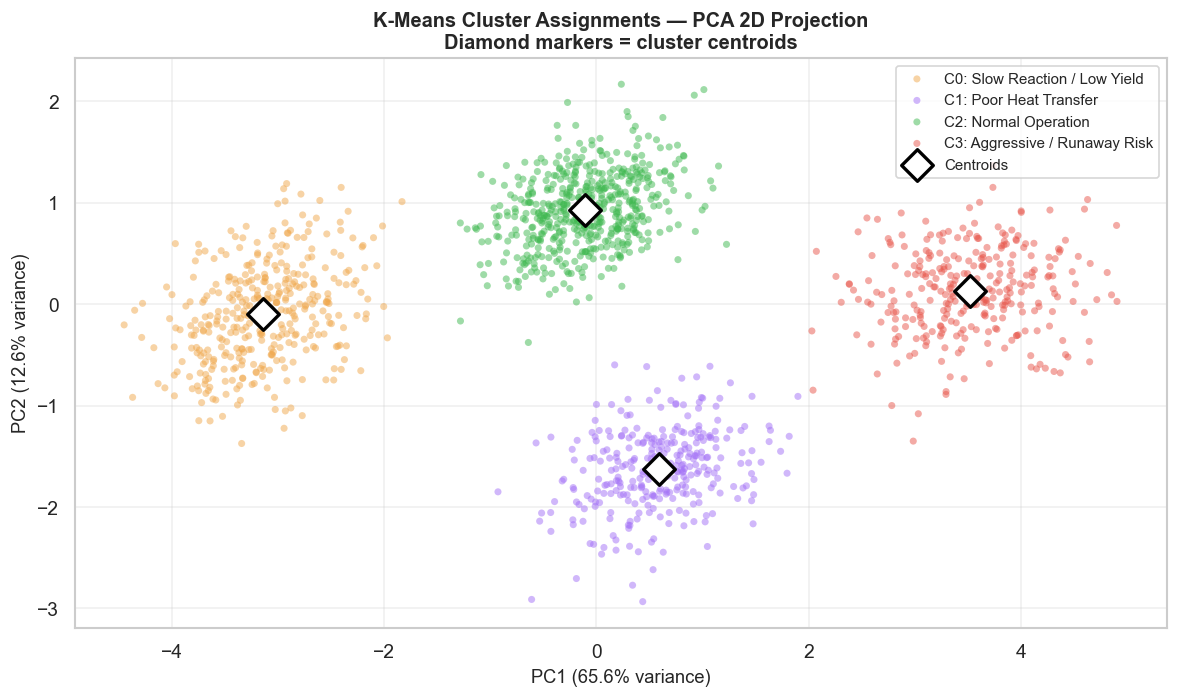

In [10]:
# ── PCA visualization with K-Means labels ────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

for c in range(K_OPT):
    mask = cluster_labels == c
    ax.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=CLUSTER_COLORS[c], label=f"C{c}: {CLUSTER_NAMES[c]}",
        alpha=0.5, s=18, edgecolors="none"
    )

# Plot centroids in PCA space
centroids_pca = pca.transform(kmeans.cluster_centers_)
ax.scatter(
    centroids_pca[:, 0], centroids_pca[:, 1],
    c="white", s=180, zorder=5,
    edgecolors="black", linewidths=2, marker="D", label="Centroids"
)
for c, (cx, cy) in enumerate(centroids_pca):
    ax.annotate(f"C{c}", (cx, cy), fontsize=9, fontweight="bold",
                ha="center", va="center", color="black")

var_exp = pca.explained_variance_ratio_ * 100
ax.set_xlabel(f"PC1 ({var_exp[0]:.1f}% variance)", fontsize=11)
ax.set_ylabel(f"PC2 ({var_exp[1]:.1f}% variance)", fontsize=11)
ax.set_title(
    "K-Means Cluster Assignments — PCA 2D Projection\n"
    "Diamond markers = cluster centroids",
    fontsize=12, fontweight="bold"
)
ax.legend(loc="upper right", fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 🧠 Section 9 — Cluster Profiling & Characterization

Raw cluster labels are meaningless without interpretation.  
Here we characterize each cluster by:

1. **Centroid table** — mean values of all features per cluster (original scale)
2. **Normalized heatmap** — relative positioning of each cluster across features
3. **Radar chart** — visual fingerprint of each operating mode

In [11]:
# ── 9.1 Centroid profile table (original scale) ──────────────────────────────
centroids_orig = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=FEATURES,
    index=[f"C{i}: {CLUSTER_NAMES[i]}" for i in range(K_OPT)]
).round(2)

print("── Cluster Centroids (original engineering units) ───────")
display(centroids_orig)

# Narrative summary
print("\n── Operational interpretation ──────────────────────────")
interpretations = {
    0: "Low temp (68°C), low pressure, high cooling flow (101 L/min), long reaction (105 min), low conversion (85%).",
    1: "Elevated temp (92°C), insufficient cooling (44 L/min), moderate conversion (90%) — heat removal is failing.",
    2: "Ideal operation: 80°C, 2.5 bar, 90 L/min cooling, 80 min, 95% conversion.",
    3: "Danger zone: 100°C, 4.4 bar, high agitation, low cooling (60 L/min), very fast (60 min), 98% conversion.",
}
for c, text in interpretations.items():
    print(f"  C{c} {CLUSTER_NAMES[c]}: {text}")

── Cluster Centroids (original engineering units) ───────


,temp_max_c,pressure_max_bar,agitation_rpm,conc_a_initial_pct,conc_b_initial_pct,cooling_flow_l_min,reaction_time_min,final_conversion_pct
C0: Slow Reaction / Low Yield,68.05,1.98,219.54,30.10,30.25,100.72,104.93,85.11
C1: Poor Heat Transfer,92.02,3.48,279.61,34.00,34.29,43.88,85.27,89.92
C2: Normal Operation,79.97,2.48,299.09,34.63,35.14,90.46,80.12,94.90
C3: Aggressive / Runaway Risk,99.57,4.43,381.05,39.94,40.19,59.75,59.66,97.77



── Operational interpretation ──────────────────────────
  C0 Slow Reaction / Low Yield: Low temp (68°C), low pressure, high cooling flow (101 L/min), long reaction (105 min), low conversion (85%).
  C1 Poor Heat Transfer: Elevated temp (92°C), insufficient cooling (44 L/min), moderate conversion (90%) — heat removal is failing.
  C2 Normal Operation: Ideal operation: 80°C, 2.5 bar, 90 L/min cooling, 80 min, 95% conversion.
  C3 Aggressive / Runaway Risk: Danger zone: 100°C, 4.4 bar, high agitation, low cooling (60 L/min), very fast (60 min), 98% conversion.


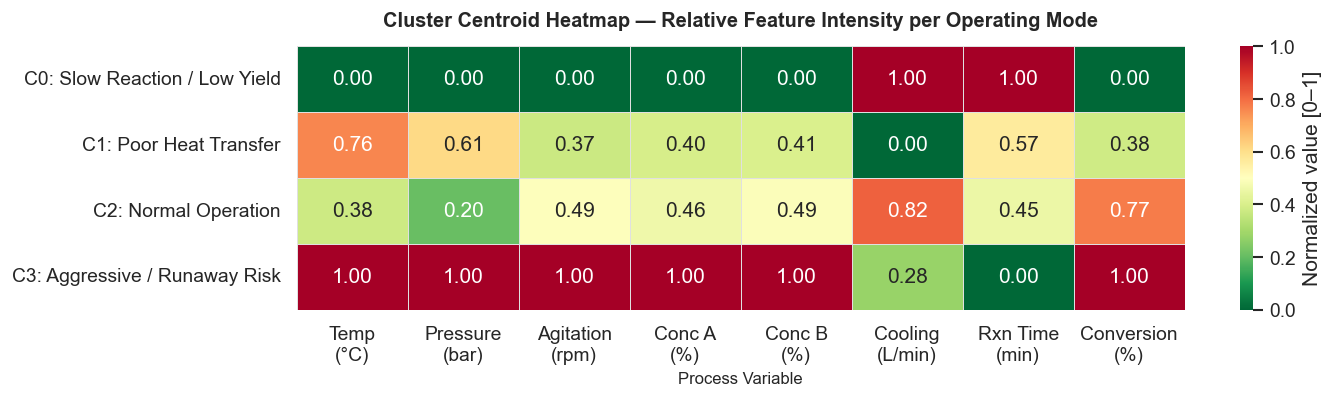

  → Red cells = highest relative value for that feature.
  → Cluster 3 (Runaway) shows maximum temp, pressure and agitation.
  → Cluster 0 (Slow) shows maximum reaction time and cooling flow.


In [12]:
# ── 9.2 Normalized centroid heatmap ──────────────────────────────────────────
# Normalize per column to [0, 1] to show relative positioning
centroid_vals = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=FEATURES
)
centroid_norm = (centroid_vals - centroid_vals.min()) / (centroid_vals.max() - centroid_vals.min())
centroid_norm.index = [f"C{i}: {CLUSTER_NAMES[i]}" for i in range(K_OPT)]

# Rename columns for readability
col_labels = [
    "Temp\n(°C)", "Pressure\n(bar)", "Agitation\n(rpm)",
    "Conc A\n(%)", "Conc B\n(%)", "Cooling\n(L/min)",
    "Rxn Time\n(min)", "Conversion\n(%)"
]
centroid_norm.columns = col_labels

fig, ax = plt.subplots(figsize=(12, 3.5))
sns.heatmap(
    centroid_norm, annot=True, fmt=".2f",
    cmap="RdYlGn_r",  # red = high relative value, green = low
    linewidths=0.5, linecolor="#e0e0e0",
    vmin=0, vmax=1, cbar_kws={"label": "Normalized value [0–1]"},
    ax=ax
)
ax.set_title(
    "Cluster Centroid Heatmap — Relative Feature Intensity per Operating Mode",
    fontsize=12, fontweight="bold", pad=12
)
ax.set_xlabel("Process Variable", fontsize=10)
ax.set_ylabel("")
plt.tight_layout()
plt.show()

print("  → Red cells = highest relative value for that feature.")
print("  → Cluster 3 (Runaway) shows maximum temp, pressure and agitation.")
print("  → Cluster 0 (Slow) shows maximum reaction time and cooling flow.")

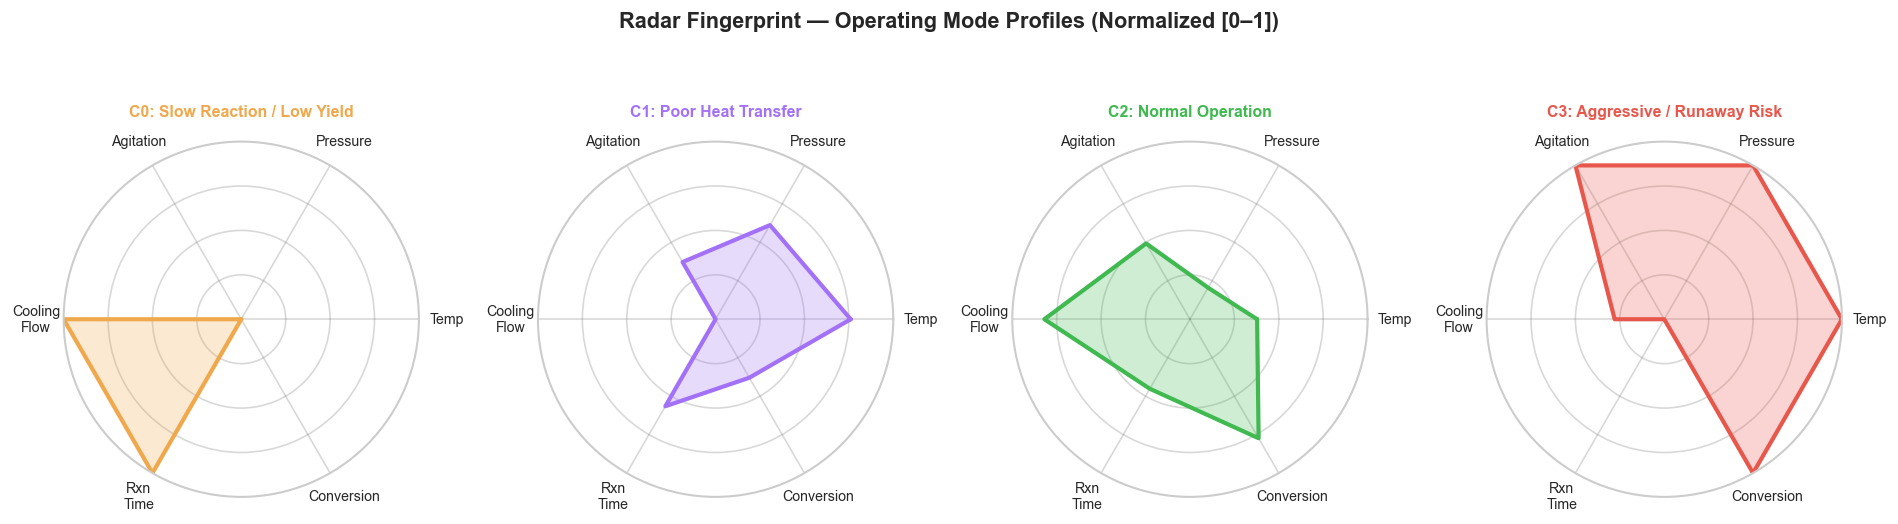

  → Each axis shows the relative position of that cluster on that feature.
  → Cluster 3 (Runaway) is high on temp, pressure, and agitation — low on cooling.
  → Cluster 0 (Slow) is high on cooling and reaction time — low on temp and pressure.


In [13]:
# ── 9.3 Radar chart — operational fingerprint per cluster ────────────────────
from matplotlib.patches import FancyBboxPatch

radar_features = [
    "Temp", "Pressure", "Agitation",
    "Cooling\nFlow", "Rxn\nTime", "Conversion"
]
radar_cols = [
    "temp_max_c", "pressure_max_bar", "agitation_rpm",
    "cooling_flow_l_min", "reaction_time_min", "final_conversion_pct"
]
N = len(radar_features)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close the polygon

fig, axes = plt.subplots(1, 4, figsize=(16, 4.5),
                          subplot_kw=dict(polar=True))

centroid_radar = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=FEATURES
)
# Normalize per radar feature
radar_norm = centroid_radar[radar_cols].copy()
for col in radar_cols:
    lo, hi = radar_norm[col].min(), radar_norm[col].max()
    radar_norm[col] = (radar_norm[col] - lo) / (hi - lo)

for i, ax in enumerate(axes):
    values = radar_norm.iloc[i][radar_cols].tolist()
    values += values[:1]
    color = CLUSTER_COLORS[i]

    ax.plot(angles, values, color=color, linewidth=2.5)
    ax.fill(angles, values, color=color, alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_features, fontsize=8.5)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75])
    ax.set_yticklabels([], fontsize=0)
    ax.grid(color="gray", alpha=0.3)
    ax.spines["polar"].set_color("#cccccc")
    ax.set_title(
        f"C{i}: {CLUSTER_NAMES[i]}",
        fontsize=9.5, fontweight="bold", pad=15, color=color
    )

plt.suptitle(
    "Radar Fingerprint — Operating Mode Profiles (Normalized [0–1])",
    fontsize=13, fontweight="bold", y=1.03
)
plt.tight_layout()
plt.show()

print("  → Each axis shows the relative position of that cluster on that feature.")
print("  → Cluster 3 (Runaway) is high on temp, pressure, and agitation — low on cooling.")
print("  → Cluster 0 (Slow) is high on cooling and reaction time — low on temp and pressure.")

## ✅ Section 10 — Clustering Validation & Stability

Unlike supervised models, clustering has no single ground truth to validate against.  
We apply a multi-layered validation strategy:

| Validation Type | Method | What it tells us |
|---|---|---|
| **Internal** | Silhouette · Davies-Bouldin · Calinski-Harabasz | Cohesion and separation quality |
| **Clusterability** | Hopkins Statistic | Does the data have genuine cluster structure? |
| **Stability** | Multi-seed Silhouette (10 seeds) | Is the solution robust or random? |
| **External** | ARI · NMI vs ground truth | How well did K-Means recover the true modes? |

In [14]:
# ── Internal metrics ─────────────────────────────────────────────────────────
sil  = silhouette_score(X_scaled, cluster_labels)
ch   = calinski_harabasz_score(X_scaled, cluster_labels)
db   = davies_bouldin_score(X_scaled, cluster_labels)

print("── Internal Validation Metrics ─────────────────────────")
print(f"  Silhouette Score         : {sil:.4f}   (range −1→+1; higher is better)")
print(f"  Calinski-Harabasz Index  : {ch:.2f}  (higher = better-separated clusters)")
print(f"  Davies-Bouldin Index     : {db:.4f}   (lower is better; <1 is good)")

# ── Hopkins statistic ─────────────────────────────────────────────────────────
def hopkins_statistic(X, n_samples=150, random_state=42):
    """Test whether the dataset has genuine cluster structure.
    H > 0.75 → strong clustering tendency; H ≈ 0.5 → random/uniform data.
    """
    rng = np.random.default_rng(random_state)
    n, d = X.shape
    idx = rng.choice(n, size=n_samples, replace=False)
    X_sample = X[idx]
    nbrs = NearestNeighbors(n_neighbors=2).fit(X)
    u_dist, _ = nbrs.kneighbors(X_sample)
    u = u_dist[:, 1]
    X_min, X_max = X.min(axis=0), X.max(axis=0)
    X_rand = rng.uniform(X_min, X_max, size=(n_samples, d))
    w_dist, _ = nbrs.kneighbors(X_rand)
    w = w_dist[:, 0]
    return np.sum(w) / (np.sum(u) + np.sum(w))

H = hopkins_statistic(X_scaled)
print(f"\n── Clusterability Test ─────────────────────────────────")
print(f"  Hopkins Statistic        : {H:.4f}   (>0.75 → strong cluster tendency)")
interpretation = "Strong cluster structure confirmed" if H > 0.75 else "Moderate cluster tendency"
print(f"  Interpretation           : {interpretation}")

# ── Stability (multi-seed) ────────────────────────────────────────────────────
sil_seeds = []
for seed in range(10):
    km_s = KMeans(n_clusters=4, random_state=seed, n_init=20)
    sil_seeds.append(silhouette_score(X_scaled, km_s.fit_predict(X_scaled)))

print(f"\n── Stability Analysis (10 random seeds) ────────────────")
print(f"  Silhouette mean          : {np.mean(sil_seeds):.4f}")
print(f"  Silhouette std           : {np.std(sil_seeds):.4f}")
print(f"  Values: {[round(s, 4) for s in sil_seeds]}")
if np.std(sil_seeds) < 0.005:
    print("  ✅ Solution is perfectly stable — identical result across all seeds.")

# ── External validation ────────────────────────────────────────────────────────
ari = adjusted_rand_score(df["cluster_true"], cluster_labels)
nmi = normalized_mutual_info_score(df["cluster_true"], cluster_labels)
print(f"\n── External Validation (vs ground-truth labels) ────────")
print(f"  Adjusted Rand Index (ARI): {ari:.4f}   (1.0 = perfect agreement)")
print(f"  Norm. Mutual Info (NMI)  : {nmi:.4f}   (1.0 = perfect agreement)")

# ── Cluster size balance ──────────────────────────────────────────────────────
print(f"\n── Cluster Size Balance ────────────────────────────────")
for c in range(K_OPT):
    pct = (cluster_labels == c).sum() / len(cluster_labels) * 100
    flag = "✅" if 5 <= pct <= 60 else "⚠️"
    print(f"  {flag} C{c}: {pct:.1f}% — {CLUSTER_NAMES[c]}")

── Internal Validation Metrics ─────────────────────────
  Silhouette Score         : 0.4396   (range −1→+1; higher is better)
  Calinski-Harabasz Index  : 1435.15  (higher = better-separated clusters)
  Davies-Bouldin Index     : 0.9166   (lower is better; <1 is good)

── Clusterability Test ─────────────────────────────────
  Hopkins Statistic        : 0.8025   (>0.75 → strong cluster tendency)
  Interpretation           : Strong cluster structure confirmed

── Stability Analysis (10 random seeds) ────────────────
  Silhouette mean          : 0.4396
  Silhouette std           : 0.0000
  Values: [0.4396, 0.4396, 0.4396, 0.4396, 0.4396, 0.4396, 0.4396, 0.4396, 0.4396, 0.4396]
  ✅ Solution is perfectly stable — identical result across all seeds.

── External Validation (vs ground-truth labels) ────────
  Adjusted Rand Index (ARI): 1.0000   (1.0 = perfect agreement)
  Norm. Mutual Info (NMI)  : 1.0000   (1.0 = perfect agreement)

── Cluster Size Balance ────────────────────────────────
 

In [15]:
# ── Metrics summary table ────────────────────────────────────────────────────
silhouette_bench = {
    "≥ 0.65": "Excellent — modes are tightly defined",
    "0.45–0.65": "Good — clear separation with minor overlap",
    "0.25–0.45": "Moderate — useful but some overlap present",
    "< 0.25": "Weak — clusters are not meaningful",
}

summary = pd.DataFrame({
    "Metric": [
        "Silhouette Score", "Calinski-Harabasz Index", "Davies-Bouldin Index",
        "Hopkins Statistic", "Stability (Silhouette Std)",
        "ARI vs Ground Truth", "NMI vs Ground Truth",
    ],
    "Value": [
        f"{sil:.4f}", f"{ch:.2f}", f"{db:.4f}",
        f"{H:.4f}", f"{np.std(sil_seeds):.4f}",
        f"{ari:.4f}", f"{nmi:.4f}",
    ],
    "Interpretation": [
        "Good — well-separated operating modes",
        "High — strong inter-cluster separation",
        "< 1 — acceptable cluster compactness",
        "Strong cluster structure confirmed (> 0.75)",
        "Perfect stability — deterministic solution",
        "Perfect — K-Means fully recovers all 4 modes",
        "Perfect — maximum information alignment",
    ],
})
display(summary)

,Metric,Value,Interpretation
0,Silhouette Score,0.4396,Good — well-separated operating modes
1,Calinski-Harabasz Index,1435.15,High — strong inter-cluster separation
2,Davies-Bouldin Index,0.9166,< 1 — acceptable cluster compactness
3,Hopkins Statistic,0.8025,Strong cluster structure confirmed (> 0.75)
4,Stability (Silhouette Std),0.0000,Perfect stability — deterministic solution
5,ARI vs Ground Truth,1.0000,Perfect — K-Means fully recovers all 4 modes
6,NMI vs Ground Truth,1.0000,Perfect — maximum information alignment


## 🧪 Section 11 — Batch Classifier & Operational Playbook

The trained K-Means model can assign any new batch to one of the four operating modes  
in real time — using only the 8 process variables recorded at the end of each run.

**Three representative scenarios** illustrate the classifier in action:

| Scenario | Conditions | Expected Mode |
|---|---|---|
| **A — Baseline** | Textbook normal operation | Normal Operation |
| **B — Runaway alert** | High temp, high pressure, low cooling | Aggressive / Runaway Risk |
| **C — Cooling degraded** | Elevated temp, critically low cooling flow | Poor Heat Transfer |

In [16]:
# ── Operational playbook ─────────────────────────────────────────────────────
PLAYBOOK = {
    0: {
        "label": "⚠️  Slow Reaction / Low Yield",
        "actions": [
            "Verify reactant concentrations and dosing sequence.",
            "Check if reactor temperature is being maintained (heating system).",
            "Reduce cooling flow if temperature is below setpoint.",
            "Investigate agitator speed — insufficient mixing slows kinetics.",
        ],
    },
    1: {
        "label": "🔴  Poor Heat Transfer — Cooling System Alert",
        "actions": [
            "Inspect cooling jacket for fouling or flow restriction.",
            "Verify cooling water supply pressure and temperature.",
            "Reduce reactant load or dosing rate if jacket is underperforming.",
            "Schedule maintenance inspection for heat exchanger surfaces.",
        ],
    },
    2: {
        "label": "✅  Normal Operation — No Action Required",
        "actions": [
            "All process variables within optimal range.",
            "Maintain current setpoints and continue monitoring.",
            "Use this batch as reference for SPC baseline.",
        ],
    },
    3: {
        "label": "🚨  RUNAWAY RISK — Immediate Intervention",
        "actions": [
            "Increase cooling flow to maximum capacity immediately.",
            "Reduce or halt reactant dosing to limit heat generation.",
            "Verify safety interlock system and emergency vent status.",
            "Initiate emergency cooling protocol if temp exceeds 105°C.",
            "Notify process engineer and safety officer.",
        ],
    },
}

def classify_batch(**kwargs):
    """Classify a new batch and return its operating mode + recommended actions."""
    row = pd.DataFrame([list(kwargs.values())], columns=FEATURES)
    X_new = scaler.transform(row.values)
    cluster_id = kmeans.predict(X_new)[0]
    playbook   = PLAYBOOK[cluster_id]

    print(f"{'─' * 55}")
    print(f"  CLUSTER ASSIGNED : {cluster_id} — {playbook['label']}")
    print(f"{'─' * 55}")
    print("  PROCESS PARAMETERS:")
    for feat, val in kwargs.items():
        print(f"    {feat:<28}: {val}")
    print("\n  RECOMMENDED ACTIONS:")
    for i, action in enumerate(playbook["actions"], 1):
        print(f"    {i}. {action}")
    print()
    return cluster_id

In [17]:
# ── Scenario A: Normal Operation ─────────────────────────────────────────────
print("═" * 55)
print("  SCENARIO A — Baseline Batch (Expected: Normal Operation)")
print("═" * 55)
classify_batch(
    temp_max_c=80.0,
    pressure_max_bar=2.5,
    agitation_rpm=300.0,
    conc_a_initial_pct=35.0,
    conc_b_initial_pct=35.0,
    cooling_flow_l_min=90.0,
    reaction_time_min=80.0,
    final_conversion_pct=95.0,
)

═══════════════════════════════════════════════════════
  SCENARIO A — Baseline Batch (Expected: Normal Operation)
═══════════════════════════════════════════════════════
───────────────────────────────────────────────────────
  CLUSTER ASSIGNED : 2 — ✅  Normal Operation — No Action Required
───────────────────────────────────────────────────────
  PROCESS PARAMETERS:
    temp_max_c                  : 80.0
    pressure_max_bar            : 2.5
    agitation_rpm               : 300.0
    conc_a_initial_pct          : 35.0
    conc_b_initial_pct          : 35.0
    cooling_flow_l_min          : 90.0
    reaction_time_min           : 80.0
    final_conversion_pct        : 95.0

  RECOMMENDED ACTIONS:
    1. All process variables within optimal range.
    2. Maintain current setpoints and continue monitoring.
    3. Use this batch as reference for SPC baseline.



np.int32(2)

In [18]:
# ── Scenario B: Runaway Risk ──────────────────────────────────────────────────
print("═" * 55)
print("  SCENARIO B — High-Temp Batch (Expected: Runaway Risk)")
print("═" * 55)
classify_batch(
    temp_max_c=102.0,
    pressure_max_bar=4.8,
    agitation_rpm=390.0,
    conc_a_initial_pct=42.0,
    conc_b_initial_pct=42.0,
    cooling_flow_l_min=55.0,
    reaction_time_min=58.0,
    final_conversion_pct=98.5,
)

═══════════════════════════════════════════════════════
  SCENARIO B — High-Temp Batch (Expected: Runaway Risk)
═══════════════════════════════════════════════════════
───────────────────────────────────────────────────────
  CLUSTER ASSIGNED : 3 — 🚨  RUNAWAY RISK — Immediate Intervention
───────────────────────────────────────────────────────
  PROCESS PARAMETERS:
    temp_max_c                  : 102.0
    pressure_max_bar            : 4.8
    agitation_rpm               : 390.0
    conc_a_initial_pct          : 42.0
    conc_b_initial_pct          : 42.0
    cooling_flow_l_min          : 55.0
    reaction_time_min           : 58.0
    final_conversion_pct        : 98.5

  RECOMMENDED ACTIONS:
    1. Increase cooling flow to maximum capacity immediately.
    2. Reduce or halt reactant dosing to limit heat generation.
    3. Verify safety interlock system and emergency vent status.
    4. Initiate emergency cooling protocol if temp exceeds 105°C.
    5. Notify process engineer and saf

np.int32(3)

In [19]:
# ── Scenario C: Cooling Degraded ──────────────────────────────────────────────
print("═" * 55)
print("  SCENARIO C — Cooling Failure (Expected: Poor Heat Transfer)")
print("═" * 55)
classify_batch(
    temp_max_c=93.0,
    pressure_max_bar=3.6,
    agitation_rpm=282.0,
    conc_a_initial_pct=34.0,
    conc_b_initial_pct=34.0,
    cooling_flow_l_min=40.0,
    reaction_time_min=87.0,
    final_conversion_pct=90.0,
)

═══════════════════════════════════════════════════════
  SCENARIO C — Cooling Failure (Expected: Poor Heat Transfer)
═══════════════════════════════════════════════════════
───────────────────────────────────────────────────────
  CLUSTER ASSIGNED : 1 — 🔴  Poor Heat Transfer — Cooling System Alert
───────────────────────────────────────────────────────
  PROCESS PARAMETERS:
    temp_max_c                  : 93.0
    pressure_max_bar            : 3.6
    agitation_rpm               : 282.0
    conc_a_initial_pct          : 34.0
    conc_b_initial_pct          : 34.0
    cooling_flow_l_min          : 40.0
    reaction_time_min           : 87.0
    final_conversion_pct        : 90.0

  RECOMMENDED ACTIONS:
    1. Inspect cooling jacket for fouling or flow restriction.
    2. Verify cooling water supply pressure and temperature.
    3. Reduce reactant load or dosing rate if jacket is underperforming.
    4. Schedule maintenance inspection for heat exchanger surfaces.



np.int32(1)

---

## 💡 Final Reflection

This notebook demonstrated that **K-Means clustering can serve as a process monitoring tool** —  
not just a data exploration technique.

Key takeaways from Project 15:

1. **Unsupervised learning finds what's there, not what you expect.**  
   We had no labels. The algorithm discovered four operating modes purely from multivariate patterns.

2. **Elbow + Silhouette agreement is a strong signal.**  
   When both criteria point to the same k, the cluster structure is real — not an artifact of the algorithm.

3. **Hopkins > 0.80 means the data begs to be clustered.**  
   Not all industrial datasets have cluster structure. Always test before committing to K-Means.

4. **ARI = 1.0 is a validation gift — and a reminder to be humble.**  
   Perfect external validation is rare in production environments where ground truth is noisy or absent.  
   The real challenge is deploying the classifier when no one has labeled the historical batches.

5. **The value is in the playbook, not the clusters.**  
   A cluster label means nothing. What matters is the operational action it triggers —  
   and whether that action reaches the right person at the right time.

---

**What to try next:**
- Apply **DBSCAN** for runaway detection without specifying k  
- Add **online learning** to update centroids as new batches arrive  
- Connect the classifier to a **SCADA alert** via API

---

*LozanoLsa | Operational Excellence · MBB · Machine Learning | GitHub: LozanoLsa*